Problem 2: Sentiment Analysis using Transformer-based Transfer Learning (5 points)

Transformer architectures, like GPT, have set new benchmarks in NLP tasks. In this problem, you will leverage the power of transfer learning using the "A Lite BERT" (ALBERT) model on sentiment analysis similar to problem 2 from the last homework assignment.

Data: The IMDB dataset is used, which is available via the datasets library. Unlike the processed version provided by Keras, this task requires the use of the raw dataset which can be accessed via:

from datasets import load_dataset
raw_datasets = load_dataset("imdb")
Use 1000 samples for validation and the rest for training.

Processing: The dataset contains raw text reviews. To ensure consistent input to the model, your task is to tokenize these reviews. The tokenization can be achieved using  AutoTokenizer from the transformers library. Please note that further installation would be required if AlbertTokenizer is used instead.

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")

In [1]:
# Package imports
# Import necessary libraries
from pathlib import Path
from dotenv import load_dotenv
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader
import torchvision
import torchvision.transforms as transforms
from IPython.display import display, Image
import time
import copy
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification


In [2]:
# Download dataset
# IMDB has: "train" (25k), "test" (25k held-out), "unsupervised" (50k unlabeled)
raw_datasets = load_dataset("imdb")
print("Data downloaded")

# Train vs validation
# Use only raw_datasets["train"]; split off 1000 as validation, rest for training.
full_train = raw_datasets["train"]
split = full_train.train_test_split(test_size=1000, seed=42)
train_dataset = split["train"]   # ~24k training
val_dataset = split["test"]     # 1000 validation

# Test: official IMDB test split (25k) — for final evaluation only, not used during training
test_dataset = raw_datasets["test"]

# Tokenization (for consistent input to ALBERT)
tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")
train_dataset = train_dataset.map(
    lambda examples: tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512),
    batched=True,
    remove_columns=["text"],
)
val_dataset = val_dataset.map(
    lambda examples: tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512),
    batched=True,
    remove_columns=["text"],
)
test_dataset = test_dataset.map(
    lambda examples: tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512),
    batched=True,
    remove_columns=["text"],
)

# DataLoaders
BATCH_SIZE = 16
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
print("Dataloaders ready")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/24000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Dataloaders ready


Architecture: You'll be using the albert-base-v2 model, which is a light BERT-based model specifically designed for transfer learning tasks. Your main objective is to fine-tune this pre-trained model on the IMDB dataset.

In [3]:
# Set up Albert Base V2

model = AutoModelForSequenceClassification.from_pretrained("albert-base-v2", num_labels=2)


model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:
## GENERAL HELPER FUNCTIONS

# BASIC TRAIN
def train(model, loader, criterion, optimizer, device):
    """
    Train the model for one epoch.

    Parameters:
        model (nn.Module): The neural network model.
        loader (DataLoader): DataLoader for training data.
        criterion: Loss function.
        optimizer: Optimization algorithm.
        device: Device to run the training on.

    Returns:
        epoch_loss (float): Average loss for the epoch.
        epoch_acc (float): Accuracy for the epoch.
    """
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * input_ids.size(0)
        logits = outputs.logits
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# BASIC EVAL
def evaluate(model, loader, criterion, device):
    # Compute 3 accuracy percentages
    """
    Evaluate the model on validation or test data.

    Parameters:
        model (nn.Module): The neural network model.
        loader (DataLoader): DataLoader for validation/test data.
        criterion: Loss function.
        device: Device to run the evaluation on.

    Returns:
        epoch_loss (float): Average loss for the epoch.
        epoch_acc (float): Accuracy for the epoch.
    """
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            running_loss += loss.item() * input_ids.size(0)

            logits = outputs.logits
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# PLOT LOSS CURVES
def plot_loss(curve, dataset, model):
    # Plot and save loss curve
    # dataset = [Training, Validation]
    output_dir = "/content/Plot JPGs Q2"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    plt.figure()
    plt.plot(curve)
    plt.xlabel("Epoch")
    if dataset == 'Training':
        plt.ylabel("Training Loss")
    elif dataset == 'Validation':
        plt.ylabel("Validation Loss")

    plt.title(f"Categorical Cross Entropy Loss Curve for {dataset} Dataset, Model: {model.__class__.__name__}")
    filename = f"{output_dir}/LossCurve_{dataset}_Dataset_Model_{model.__class__.__name__}.jpg"

    plt.savefig(filename)
    plt.close()

# MODEL TRAIN
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=50):
    """
    Train the model and evaluate on validation data after each epoch.

    Parameters:
        model (nn.Module): The neural network model.
        train_loader (DataLoader): DataLoader for training data.
        val_loader (DataLoader): DataLoader for validation data.
        criterion: Loss function.
        optimizer: Optimization algorithm.
        device: Device to run the training on.
        num_epochs (int): Number of training epochs.

    Returns:
        Training and validation loss and accuracy.
    """
    training_loss_curve = []
    validation_loss_curve = []
    training_accuracy = []
    validation_accuracy = []

    for epoch in range(num_epochs):
        train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        training_loss_curve.append(train_loss)
        training_accuracy.append(train_acc)
        validation_loss_curve.append(val_loss)
        validation_accuracy.append(val_acc)

        print(f'Epoch {epoch+1}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    return training_loss_curve, validation_loss_curve, training_accuracy, validation_accuracy

Training: The fine-tuning process requires careful selection of parameters. Given the complexity and capabilities of the Albert model:

1. Batch Size:  Start with a smaller batch size (16) to ensure that the model fits into GPU memory. Batch size has a significant impact on the model's performance and convergence rate.
2. Learning Rate: Consider a starting LR of 1e-5 with a weight decay of 0.01 with Adam as the optimizer. Transformers are sensitive to the learning rate.
3. Epochs: Given that you're leveraging transfer learning, 10 might suffice as the model has already learned useful representations from vast amounts of data.
This training process will take hours on CPU. Please use Google Colab for this problem and ensure you are using the T4 GPU runtime to train the model in about 20 min/epoch. On other GPU machines, you can adjust the batch number accordingly.
4. Evaluation: After training, evaluate the model's performance on the test data to get an understanding of its generalization capability.

In [5]:
# Train model and evaluate

MAX_EPOCHS = 10
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01


# Detect Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move model to device
model.to(device)

# Define Optimizer (Adam with LR 1e-5 and weight_decay 0.01)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Train
training_loss_curve, validation_loss_curve, training_accuracy, validation_accuracy = train_model(
    model, train_loader, val_loader, criterion, optimizer, device, MAX_EPOCHS
)

# Evaluate final test
final_test_loss, test_acc = evaluate(model, test_loader, criterion, device)

# Save plots
plot_loss(training_loss_curve, "Training", model)
plot_loss(validation_loss_curve, "Validation", model)

# return results
row = {
    'Model Name': model.__class__.__name__,
    'Epochs': MAX_EPOCHS,
    'Training Accuracy (%)': training_accuracy[-1] * 100.0,
    'Validation Accuracy (%)': validation_accuracy[-1] * 100.0,
    'Test Accuracy (%)': test_acc * 100.0,
    'Final Test Loss': final_test_loss
}
print(row)

Using device: cuda
Epoch 1/10 | Train Loss: 0.2342 | Train Acc: 0.9105 | Val Loss: 0.2110 | Val Acc: 0.9180
Epoch 2/10 | Train Loss: 0.1535 | Train Acc: 0.9446 | Val Loss: 0.1864 | Val Acc: 0.9430
Epoch 3/10 | Train Loss: 0.1145 | Train Acc: 0.9605 | Val Loss: 0.1936 | Val Acc: 0.9360
Epoch 4/10 | Train Loss: 0.0869 | Train Acc: 0.9709 | Val Loss: 0.2545 | Val Acc: 0.9120
Epoch 5/10 | Train Loss: 0.0671 | Train Acc: 0.9785 | Val Loss: 0.2395 | Val Acc: 0.9320
Epoch 6/10 | Train Loss: 0.0601 | Train Acc: 0.9795 | Val Loss: 0.2638 | Val Acc: 0.9240
Epoch 7/10 | Train Loss: 0.0450 | Train Acc: 0.9858 | Val Loss: 0.2692 | Val Acc: 0.9240
Epoch 8/10 | Train Loss: 0.0447 | Train Acc: 0.9852 | Val Loss: 0.2147 | Val Acc: 0.9280
Epoch 9/10 | Train Loss: 0.0474 | Train Acc: 0.9835 | Val Loss: 0.2655 | Val Acc: 0.9240
Epoch 10/10 | Train Loss: 0.0406 | Train Acc: 0.9862 | Val Loss: 0.3074 | Val Acc: 0.9070
{'Model Name': AlbertForSequenceClassification(
  (albert): AlbertModel(
    (embeddings):

Visualization:

Plot the loss for both the training and validation sets, and the accuracy for the validation set across epochs to analyze the model's performance.

Deliverables:

1. Model Accuracy and Loss Curves: Report the model validation accuracy and both training and validation loss over epochs with the plots detailed above.
2. Analysis of Model Performance: Discuss the results obtained from the model. This should include:
- Examination of whether the model overfits or underfits the training data.
- Compare this model's performance to the one you obtained in HW2 while also considering the different data splits.
- Analysis of loss and accuracy for potential insights.
- Suggest improvements to the model and training process.
3. Code and Resources: Provide working code, accompanied by results and plots.
4. Bonus (+1) Prediction: Predict the label and provide the class probability of the statement "This movie was really amazing!"

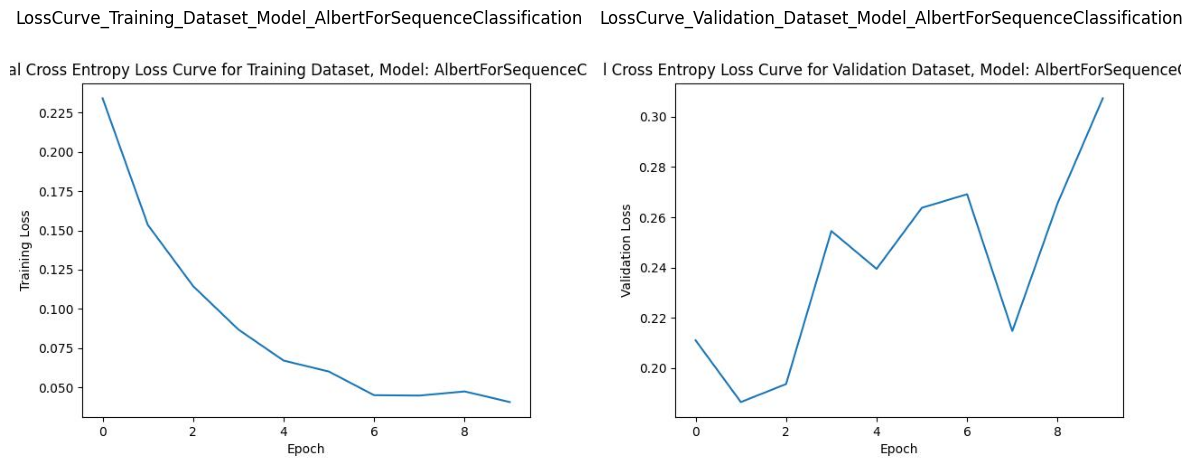

In [8]:
# Plot Loss Curves
# dataset = [Training, Validation]
plot_folder = "/content/Plot JPGs Q2"

# List all jpg files in the plot folder
plot_files = [f for f in os.listdir(plot_folder) if f.lower().endswith('.jpg')]
# Sort to ensure consistent order: e.g., Training first, Validation second
plot_files.sort()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, plot_file in zip(axes, plot_files):
    img = mpimg.imread(os.path.join(plot_folder, plot_file))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(plot_file.replace('.jpg', ''))

plt.tight_layout()
plt.show()

In [9]:
# BONUS
# Predict label and class probability of the following statement
TEST_STATEMENT = "This movie was really amazing!"

# Preprocessing: use the same ALBERT tokenizer settings as training
encoding = tokenizer(
    TEST_STATEMENT,
    padding="max_length",
    truncation=True,
    max_length=512,
    return_tensors="pt",
)
encoding = {k: v.to(device) for k, v in encoding.items()}

# Predict (PyTorch + Hugging Face)
model.eval()
with torch.no_grad():
    outputs = model(**encoding)
    probs = torch.softmax(outputs.logits, dim=-1).squeeze(0).cpu().numpy()

pred_class = int(np.argmax(probs))
class_labels = ["Negative", "Positive"]

print(f"Statement: '{TEST_STATEMENT}'")
print(f"Predicted Class: {class_labels[pred_class]}")
print(f"Class Probabilities: {probs}")

Statement: 'This movie was really amazing!'
Predicted Class: Positive
Class Probabilities: [0.02179905 0.9782009 ]


**Discussion**

Curve analysis
- Training loss curve: Descends rapidly the first 5 epochs then slows down
- Validation loss curve: Very spiky and inconsistent trend

Model fit
- Final training accuracy: 98.62% (last epoch) indicates high fit to training set.
- Final validation accuracy: 90.70% (last epoch) indicating moderate generalization.
- Final test accuracy / loss: 91.27% test accuracy, final test loss = 0.2860.
- Over/Underfit: Between the curves and the final accuracies, it seems that the model has slightly overfit but still maintaining good generalization (as evidenced by the small gap between validation and test accuracy). Earlier stopping around Epoch 6 or 7  or adding dropout may benefit robustness.

HW2 comparison (non-transformer baseline): While the training and validation losses started much higher, because of training over 30 epochs, the HW2 TextCNN was able to train much closer to zero loss, all the while overfitting more. However, Albert's validation and test accuracies were higher than HW2 TextCNN. This suggests that while the TextCNN way overfit the training data, the transfer-learned Albert started at a lower loss and demonstrated improvement through training while maintaining some model generalization. 